Calculate the HMF. This is the cleaned up version.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/Users/eb35267/Desktop/research/mpl_style/estyle.mplstyle')
plt.style.use('/Users/eb35267/Desktop/research/mpl_style/notebook_style.mplstyle')

from classy import Class
import astropy.units as u
import zeus21
from scipy.interpolate import RegularGridInterpolator
import matplotlib.ticker as ticker

In [2]:
def classy_cosmology(Omega_b, Omega_m, h, k_max, z_max = 10):
    """
    Calculate cosmology with Class
    Parameters:
        Omega_b [float]: Omega baryons
        Omega_m [float]: Omega matter (Omega matter >= Omega baryons)
        h [float]: dimensionless Hubble parameter
        k_max [float]: maximum wavenumber (1/Mpc)
        z_max [float]: maximum redshift
    Returns:
        cosmo [Class object]: computed cosmology
    """
    #Initialize the cosmology
    params = {'output': 'mPk',
          'non linear': 'halofit',
          'Omega_b': Omega_b,
          'Omega_cdm': Omega_m - Omega_b,
          'h': h,
          'P_k_max_1/Mpc': k_max,
          'z_max_pk': z_max
    }
    cosmo = Class()
    cosmo.set(params)

    # Compute everything, store it in cosmo
    cosmo.compute()

    return cosmo

In [3]:
def hmf_zeus(Omega_b, Omega_m, h, z_min = 0, HMF_CHOICE = 'ST'):
    """
    Initiate Zeus21 & calculate the relevant parameters
    Inputs:
        Omega_b [float]: Omega baryons
        Omega_m [float]: Omega matter (Omega matter > Omega baryons always)
        h [float]: dimensionless hubble parameter
        z_min [float]: minimum redshift
        HMF_CHOICE [str]: choice of 'ST' for Sheth-Tormen or 'Yung' for the Tinker08 form of the HMF
    Returns:
        HMFintclass: Zeus object that has a lot of functionality for HMF calculations
    """
    
    # Zeus takes their parameters scaled by the hubble constant
    omegab = Omega_b * h**2
    omegac = (Omega_m - Omega_b) * h**2 # CDM
    CosmoParams_input = zeus21.Cosmo_Parameters_Input(omegab, omegac, h, zmin_CLASS = z_min, HMF_CHOICE = HMF_CHOICE) 


    # Run the cosmology & get parameters out
    ClassyCosmo = zeus21.runclass(CosmoParams_input)
    CosmoParams = zeus21.Cosmo_Parameters(CosmoParams_input, ClassyCosmo)

    # Get the HMF interpolator that I need for comparison HMFs from Zeus
    HMFintclass = zeus21.HMF_interpolator(CosmoParams,ClassyCosmo)

    return HMFintclass

In [23]:
# Parameters that define the cosmology
Omega_b = 0.04927
Omega_m = 0.3156
h = 0.6727 #H0/100
k_max = 1e3

In [75]:
# Compute the comsology
cosmo = classy_cosmology(Omega_b, Omega_m, h, k_max)

In [76]:
# Get Zeus HMF class for comparison later
HMFintclass = hmf_zeus(Omega_b, Omega_m, h)

Text(0, 0.5, 'P(k) / $Mpc^3$')

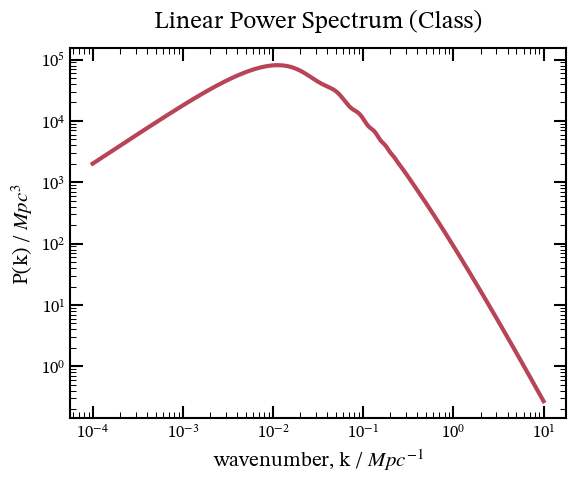

In [26]:
# Plot the linear power spectrum

#Specify k and z
k = np.logspace(-4, 1, num=1000)
z = 0

# Calculate the linear power spectrum
Plin = np.array([cosmo.pk_lin(ki, z) for ki in k])

# Plot
fig, ax = plt.subplots()
ax.plot(k, Plin)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Linear Power Spectrum (Class)')
ax.set_xlabel(r'wavenumber, k / $Mpc^{-1}$')
ax.set_ylabel(r'P(k) / $Mpc^3$')

$\sigma^2(R) = \frac{1}{2\pi^2} \int_0^{\infty}k^2P(k)W^2(kR)dk = \langle \delta \rangle$ \
$W(kR) = \frac{3(sin(kR)-kRcos(kR))}{(kR)^3}$

In [95]:
def sigma_integrand(k, R, z):
    """
    Helper function for calc_sigma
    """
    P = cosmo.pk_lin(k, z)
    W = 3*(np.sin(k*R)-(k*R*np.cos(k*R)))/((k*R)**3)
    return (1/(2*np.pi**2))*k**2*P*W**2

In [96]:
def calc_sigma(R, k_range, z=0):
    """
    Calculate mass variance, sigma(R)
    Inputs:
        R [float]: radius [Mpc]
        k_range [1darr]: range of wavenumbers to evaluate over (each in Mpc^-1)
        z [float]: redshift
    Returns:
        sigma(R) [float]: see equation above
    """
    return np.sqrt(np.trapz([sigma_integrand(k, R=R, z=z) for k in k_range], k_range))

In [97]:
# Calculate matter variance, sigma(R) from the equation
R_values = np.logspace(-2, 2, 1000)
sigma = np.zeros_like(R_values)
for i, R in enumerate(R_values):
    sigma[i] = calc_sigma(R, k, z) # Uses the same values of k defined for the matter power spectrum

In [98]:
# For comparison...

# Calculate matter variance with Class
sigma_class = [cosmo.sigma(R, z) for R in R_values]

# Calculate matter variance with Zeus
sigma_zeus = HMFintclass.sigmaR_int(R_values, z)

In [99]:
def percent_diff_plot(x, y0, y1, labels, other_data = None):
    """
    Make a plot showing 2 different datasets & their percent difference
    Inputs:
        x [1darray]: x values taken by both datasets
        y0 [1darray]: corresponding y values of the first dataset (this will be the dataset used for comparison)
        y1 [1darray]: corresponding y values of the second dataset
        labels [list]: list of labels
        other_data [list of 1darrays]: other data that will be plotted but whose percent difference will not be calculated
    Returns:
        fig, ax
    """
    percent_diff = np.abs(y1-y0) / y0

    fig, ax = plt.subplots(2, 1, sharex = True, height_ratios = (2, 1.5))
    plt.subplots_adjust(hspace = 0.1)

    ax[0].plot(x, y0, label = labels[0])
    ax[0].plot(x, y1, label = labels[1], linestyle = '--')
    if other_data is not None:
        [ax[0].plot(x, dat, label = lab, linestyle = 'dotted') for (dat, lab) in zip(other_data, labels[2:])]
    ax[0].legend()

    ax[1].plot(x, percent_diff, color = '#111114')
    ax[1].yaxis.set_major_formatter(ticker.FuncFormatter(custom_percent_formatter)) # Format percent difference with % symbols

    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    ax[0].set_yscale('log')

    return fig, ax

def custom_percent_formatter(x, pos):
    """Format as percentage."""
    return f"{x * 100:.2f}%"

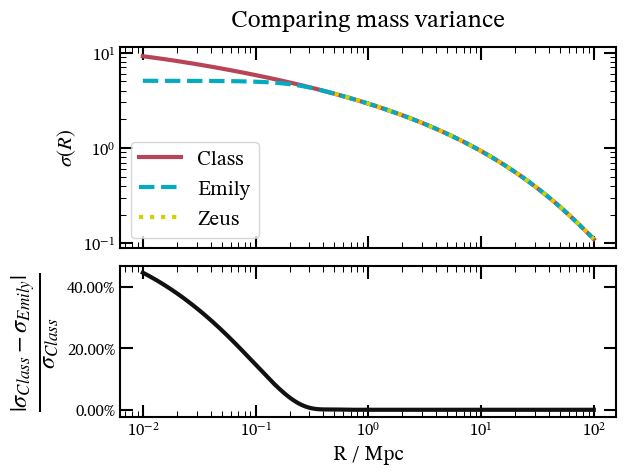

In [100]:
# Plot matter variancabse
fig, ax = percent_diff_plot(R_values, sigma_class, sigma, labels = ['Class', 'Emily', 'Zeus'], other_data = [sigma_zeus])

ax[0].set_ylabel(r'$\sigma(R)$')
ax[1].set_xlabel('R / Mpc')
ax[1].set_ylabel(r'$\frac{|\sigma_{Class} - \sigma_{Emily}|}{\sigma_{Class}}$', fontsize = 25)

ax[0].set_title('Comparing mass variance')

# fig.savefig('/Users/eb35267/Desktop/research/figures/sigmaR.png', bbox_inches='tight')

Calculate the HMF with the Press-Schechter fitting function, which defines the fraction of mass collapsed: \
$f_{PS}(\sigma) = \sqrt{\frac{2}{\pi}} \frac{\delta_c}{\sigma} \exp[-\frac{\delta_c^2}{2\sigma^2}]$ \
where $\delta_c = 1.686$ (critical overdensity for spherical collapse) \
or the Sheth-Tormen fitting function: \
$f_{ST}(\sigma) = A \sqrt{\frac{2a}{\pi}}[1+(\frac{\sigma^2}{a\delta_c^2})^p] \exp[-\frac{\delta_c^2}{2\sigma^2}]$

In [33]:
def calc_fPS(sigma, delta_c = 1.686):
    """
    Evaluate the Press-Schechter fitting function
    Inputs:
        sigma [1darray]: mass variance
        delta_c [float]: critical overdensity for spherical collapse
    Returns:
        f(sigma) [1darra]: sqrt(2/pi)*delta_c/sigma*exp(-delta_c^2/2sigma^2)
    """
    return np.sqrt(2/np.pi)*delta_c/sigma*(np.e**(-(delta_c**2)/(2*sigma**2)))

In [34]:
def calc_fST(sigma, delta_c = 1.686, A = 0.3222, a = 0.707, p = 0.3):
    """
    Evaluate the Sheth-Tormen fitting function
    Inputs:
        sigma [1darray]: mass variance
        (delta_c, A, a, p) [floats]: parameters of the Sheth-Tormen fitting function (see above)
    """
    return A*np.sqrt(2*a/np.pi)*(1+(sigma**2/(a*delta_c**2)))**p*np.exp(-(a*delta_c**2/(2*sigma**2)))

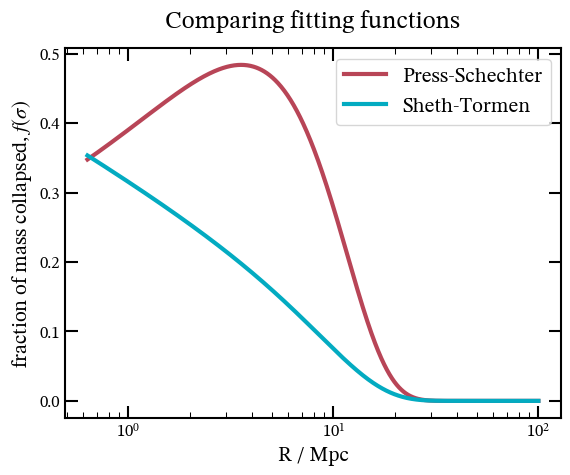

In [35]:
# Calculate & plot Press-Schechter fitting function

fPS = calc_fPS(sigma)
fST = calc_fST(sigma)

fig, ax = plt.subplots()
ax.plot(R_values, fPS, label = 'Press-Schechter')
ax.plot(R_values, fST, label = 'Sheth-Tormen')
ax.set_title('Comparing fitting functions')
ax.set_ylabel(r'fraction of mass collapsed, $f(\sigma)$')
ax.set_xlabel('R / Mpc')
ax.set_xscale('log')
ax.legend()

$\frac{dn}{d\ln M} = M*\frac{\rho_0}{M^2}*f(\sigma)*|\frac{d\ln\sigma}{d\ln M}|$ \
Use $\frac{d\ln\sigma}{d\ln M} = \frac{d\sigma}{dM} * \frac{M}{\sigma}$ \
where $\rho_0$ is the cosmology-dependent mean density and: \
$M = \frac{4\pi\rho_{(0,M)}}{3} R^3$ -- use this to turn $\sigma(R)$ into $\sigma(M)$ \
$\rho_0 = \Omega_{tot} * \rho_{crit, 0}$ \
$\rho_{crit, 0} = \frac{3H_0^2}{8\pi G}$

In [36]:
def calc_rho_0(cosmo, Omega_tot = 1):
    """
    Calculate the mean density of the universe
    Inputs:
        cosmo: cosmology computed with Class
        Omega_tot [float]: ratio of the total density of the universe to the critical density. This should be 1 if the universe is flat
                           (so most cosmologies)
    Returns:
        rho_0 [float]: mean density of the universe
    """

    # Put constants in the right units to calculate rho_crit = 3H_0**2 / 8*pi*G
    c = 3e8*u.m/u.s # speed of light
    H0 = (cosmo.Hubble(z)/u.Mpc*c).to(u.s**-1) # H0 comes divided by c by default, so we have to take that out
    G = 6.67430e-11* u.m**3 * u.s**-2 * u.kg**-1

    rho_crit_0 = ((3*H0**2)/(8*np.pi*G)).to(u.Msun/u.Mpc**3)

    return (Omega_tot*rho_crit_0).value


In [37]:
def M_to_R (M, rho_0, Omega_m):
    """
    Convert a mass to the radius of a sphere that would enclose that mass given the mean density of the universe.
    Inputs:
        M [float]: mass (M_sun)
        rho_0 [float]: mean density of the universe (M_sun / Mpc^3)
        Omega_m [float]: Omega matter
    Returns:
        R [float]: radius (Mpc) of a sphere that would enclose the given mass. R = (3M/4*pi*rho_0_m)^1/3
    """

    rho_0_m = Omega_m * rho_0 # This is the mean !matter! density of the universe, which is what we're concerned with here

    return (3*M/(4*np.pi*rho_0_m))**(1/3)

In [39]:
def calc_sigmaM(M_vals, rho_0, Omega_m, k, z = 0):
    """
    Calculate the mass variance as a function of masses instead of radii
    Inputs:
        M_vals [1darr]: mass range for evalutation (M_sun)
        rho_0 [float]: mean density of the universe (M_sun / Mpc^3)
        Omega_m [float]: Omega matter
        k [1darray]: range of wavenumbers to evaluate the mass variance (each one has units Mpc^-1)
        z [float]: redshift
    Returns:
        sigma(M) [1darray]: mass variance for each input M_val
    """

    R_vals = [M_to_R(M, rho_0, Omega_m) for M in M_vals]

    return np.array([calc_sigma(R, k, z) for R in R_vals])

Text(0.5, 0, 'Mass / $M_{\\odot}$')

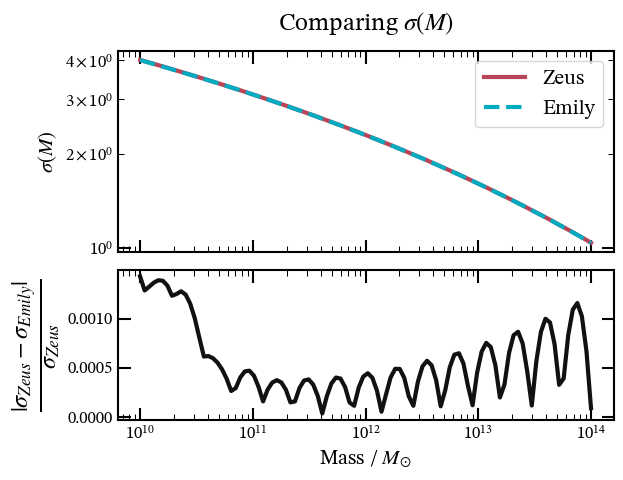

In [105]:
# Calculate sigma(M)
rho_0 = calc_rho_0(cosmo)
M_vals = np.logspace(10, 14, 100)
sigmaM = calc_sigmaM(M_vals, rho_0, Omega_m, k)

# Calculate sigma(M) with Zeus
sigmaM_zeus = HMFintclass.sigma_int(M_vals, z)

# Plot difference
fig, ax = percent_diff_plot(M_vals, sigmaM_zeus, sigmaM, labels = ['Zeus', 'Emily'])
ax[0].set_title(r'Comparing $\sigma(M)$')
ax[0].set_ylabel(r'$\sigma(M)$')
ax[1].set_yscale('linear')
ax[1].set_ylabel(r'$\frac{|\sigma_{Zeus} - \sigma_{Emily}|}{\sigma_{Zeus}}$', fontsize = 25)
ax[1].set_xlabel(r'Mass / $M_{\odot}$')

# fig.savefig('/Users/eb35267/Desktop/research/figures/sigma_M_problem.png', bbox_inches='tight')

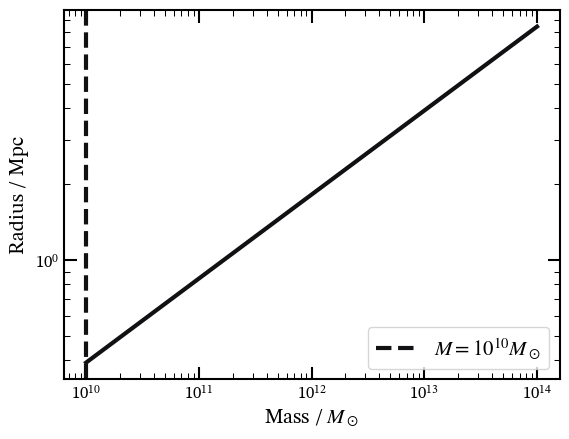

In [106]:
fig, ax = plt.subplots()
ax.plot(M_vals, M_to_R(M_vals, rho_0, Omega_m), color = '#111114')
ax.set_xlabel(r'Mass / $M_\odot$')
ax.set_ylabel('Radius / Mpc')
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(x=1e10, label = r'$M = 10^{10} M_\odot$', linestyle = '--', color = '#111114')
ax.legend()

# fig.savefig('/Users/eb35267/Desktop/research/figures/r_vs_m.png', bbox_inches='tight')

Text(0.5, 0, 'Mass / $M_{\\odot}$')

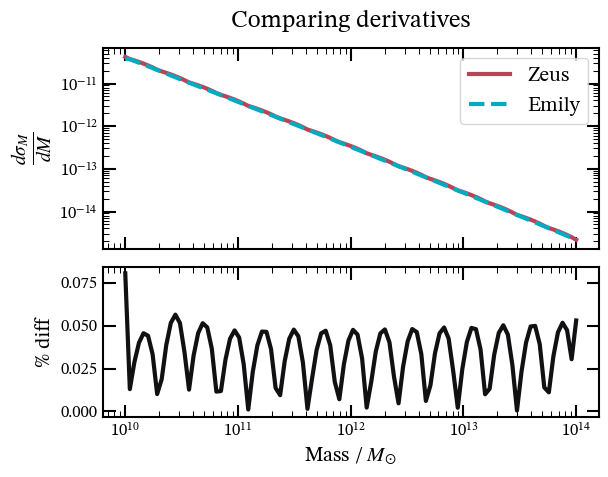

In [107]:
sigma_deriv = np.abs(np.gradient(sigmaM, M_vals))

# Calculate the derivative with Zeus
sigma_deriv_zeus = np.abs(HMFintclass.dsigmadM_int(M_vals, z))

# Compare
fig, ax = percent_diff_plot(M_vals, sigma_deriv_zeus, sigma_deriv, labels = ['Zeus', 'Emily'])

ax[0].set_title('Comparing derivatives')
ax[0].set_ylabel(r'$\frac{d\sigma_M}{dM}$', fontsize = 20)
ax[1].set_yscale('linear')
ax[1].set_ylabel('% diff')
ax[1].set_xlabel(r'Mass / $M_{\odot}$')

# fig.savefig('/Users/eb35267/Desktop/research/figures/dsigmadM_problem.png', bbox_inches='tight')

In [108]:
def calc_HMF_ST(M_vals, k, cosmo):
    """
    Calcule dn/dlnM
    Inputs: 
        M_vals [1darr]: mass range for evalutation (M_sun)
        k [1darray]: range of wavenumbers to evaluate the mass variance (each one has units Mpc^-1)
        cosmo [Class object]: computed cosmology
    Returns:
        dn/dlnM
    """
    Omega_m = cosmo.pars['Omega_b'] + cosmo.pars['Omega_cdm']
    rho_0 = calc_rho_0(cosmo)

    sigmaM= calc_sigmaM(M_vals, rho_0, Omega_m, k)
    fST = calc_fST(sigmaM)
    sigmaM_deriv = np.abs(np.gradient(sigmaM, M_vals))

    return rho_0/sigmaM * fST * sigmaM_deriv

Text(0.5, 1.0, 'Comparing Sheth-Tormen Halo Mass Functions')

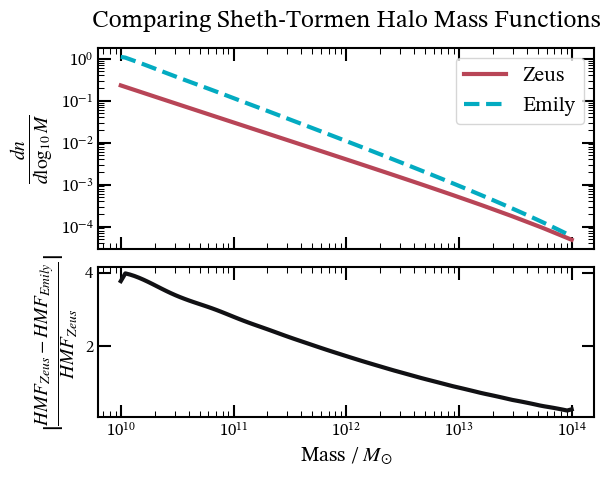

In [109]:
HMF_ST_eq = calc_HMF_ST(M_vals, k, cosmo)
HMF_ST_Zeus = HMFintclass.HMF_int(M_vals, z=0) * M_vals # HMF from Zeus is given as dn/dM, so we multiply by M to make it dn/dlnM (see notes
                                                        # from January 4th where I prove this)

fig, ax = percent_diff_plot(M_vals, HMF_ST_Zeus*np.log(10), HMF_ST_eq*np.log(10), labels = ['Zeus', 'Emily']) # Convert to dn/dlog10M for 
                                                                                                                # comparison with
                                                                                                            # Bullock & Boylan-Kolchin, 2017
ax[0].set_ylabel(r'$\frac{dn}{d\log_{10}M}$', fontsize = 20)
ax[1].set_ylabel(r'$|\frac{HMF_{Zeus} - HMF_{Emily}}{HMF_{Zeus}}|$', fontsize = 20)
ax[1].set_yscale('linear')
ax[1].set_xlabel(r'Mass / $M_{\odot}$')
ax[0].set_title('Comparing Sheth-Tormen Halo Mass Functions')

# Tests

In [77]:
from zeus21.inputs import Cosmo_Parameters, Cosmo_Parameters_Input
zeus21.cosmology.cosmo_wrapper(Cosmo_Parameters_Input)
zeus_r = zeus21.cosmology.RadofMh(Cosmo_Parameters, M_vals)

AttributeError: type object 'Cosmo_Parameters_Input' has no attribute 'omegab'

In [ ]:
Cosmo_Parameters_Input